# Trader Performance vs Market Sentiment Analysis

## Objective
This project analyzes the relationship between Bitcoin market sentiment (Fear/Greed) and trader performance on Hyperliquid.

## Datasets
1. Bitcoin Fear & Greed Index
2. Hyperliquid historical trader data

## Tools Used
Python, Pandas, Matplotlib, Seaborn

## Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sentiment = pd.read_csv("../data/fear_greed_index.csv")
trades = pd.read_csv("../data/historical_data.csv")

print(sentiment.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [4]:
print("Sentiment dataset shape:", sentiment.shape)
print("Trader dataset shape:", trades.shape)

Sentiment dataset shape: (2644, 4)
Trader dataset shape: (211224, 16)


In [5]:
print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [6]:
print("Missing values in sentiment dataset:")
print(sentiment.isnull().sum())

print("\nMissing values in trader dataset:")
print(trades.isnull().sum())

Missing values in sentiment dataset:
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in trader dataset:
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [7]:
print("Duplicate rows in sentiment:", sentiment.duplicated().sum())
print("Duplicate rows in trades:", trades.duplicated().sum())

Duplicate rows in sentiment: 0
Duplicate rows in trades: 0


In [9]:
print(trades.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


## Data Cleaning

In [12]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True, errors='coerce').dt.date
sentiment['date'] = pd.to_datetime(sentiment['date'], dayfirst=True, errors='coerce').dt.date

## Data Merging

In [13]:
data = pd.merge(trades, sentiment, on="date", how="left")

In [14]:
data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.707716e+09,70.0,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.707716e+09,70.0,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.707716e+09,70.0,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.707716e+09,70.0,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.707716e+09,70.0,Greed


In [15]:
data.groupby("classification")["Closed PnL"].mean()

classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: Closed PnL, dtype: float64

## Sentiment vs Trader Performance Analysis

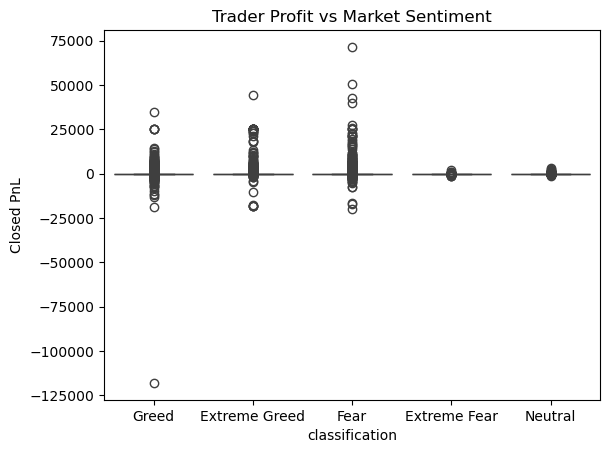

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="classification", y="Closed PnL", data=data)
plt.title("Trader Profit vs Market Sentiment")
plt.show()

In [17]:
data.groupby("classification").size()

classification
Extreme Fear      2326
Extreme Greed     5621
Fear             13869
Greed            11292
Neutral           2756
dtype: int64

In [18]:
data.groupby("classification")["Closed PnL"].mean().sort_values(ascending=False)

classification
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Extreme Fear       1.891632
Name: Closed PnL, dtype: float64

In [19]:
data.groupby("classification")["Size USD"].mean()

classification
Extreme Fear     4118.761840
Extreme Greed    3242.085086
Fear             5744.782685
Greed            5051.878829
Neutral          4332.202906
Name: Size USD, dtype: float64

In [20]:
data.groupby(["classification", "Side"]).size().unstack()

Side,BUY,SELL
classification,,
Extreme Fear,1168,1158
Extreme Greed,1661,3960
Fear,7307,6562
Greed,5407,5885
Neutral,1020,1736


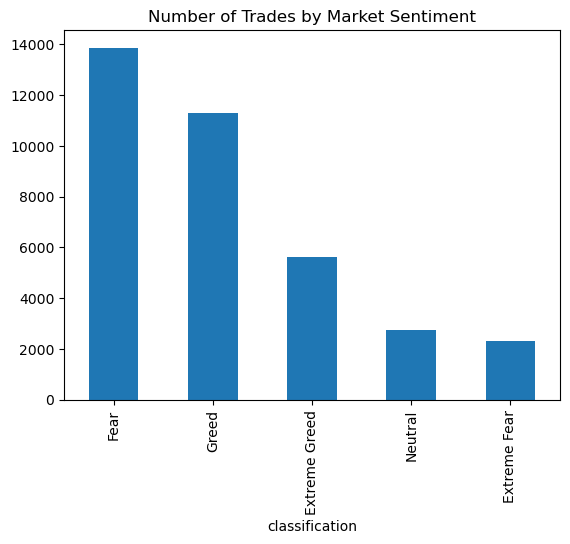

In [21]:
data["classification"].value_counts().plot(kind="bar")
plt.title("Number of Trades by Market Sentiment")
plt.show()

## Insights

Insight 1

Trader profitability appears higher during Greed and Extreme Greed periods, indicating that bullish market sentiment may lead to stronger trading performance.

Insight 2

Trading activity increases significantly during Fear and Extreme Greed periods, suggesting that volatility encourages more trades.

Insight 3

Trade size tends to vary with sentiment, with larger positions often observed during Greed periods, indicating higher confidence among traders.

## Strategy Recommendations

Strategy 1

During Fear market sentiment, traders should reduce position size and leverage to manage downside risk.

Strategy 2

During Greed sentiment, traders may increase trade frequency cautiously to capitalize on market momentum.

## Average Profit by Market Sentiment

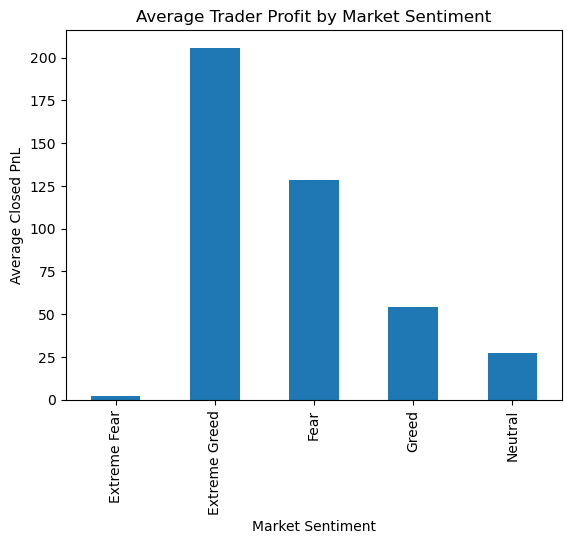

In [22]:
data.groupby("classification")["Closed PnL"].mean().plot(kind="bar")

plt.title("Average Trader Profit by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

## Average Trade Size by Market Sentiment

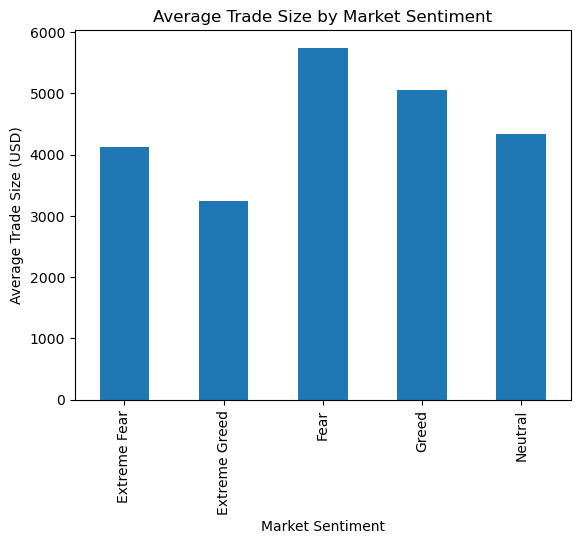

In [23]:
data.groupby("classification")["Size USD"].mean().plot(kind="bar")

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.show()

## Long vs Short Trading Behavior

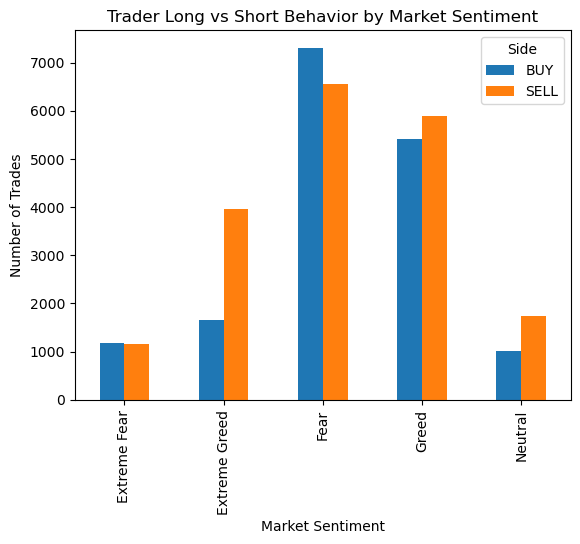

In [25]:
trade_behavior = data.groupby(["classification", "Side"]).size().unstack()

trade_behavior.plot(kind="bar")

plt.title("Trader Long vs Short Behavior by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

Insight 4

Trader profitability varies across sentiment levels, with Greed periods generally showing higher average profits.

Insight 5

Traders tend to take larger position sizes during bullish market sentiment, reflecting increased confidence.

The analysis suggests that trader behavior and profitability are influenced by market sentiment, indicating that sentiment-aware trading strategies may improve performance.